# EDA On Lending Loan Dataset

### Dataset Info
- **Dataset**  : LendingClub Loan Data (2007–2018)
- **Source**  : LendingClub — the largest US peer-to-peer lending platform
- **Records**  : ~2 million loan applications
- **Columns used**  : 23 (reduced from 151)
- **Time Period**  : 2007 to 2018     
- **What this dataset contains**  :
    Every row is one loan issued by LendingClub. It captures borrower profile, loan characteristics, and final loan outcome — making it ideal for credit risk analysis
- **Why this dataset**:
    Real-world, large-scale, messy financial data with genuine business relevance — used widely in industry for default prediction, risk modeling, and lending strategy.

### Import Libraries
* Numpy for Numerical Series and array exporation
* Pandas for Analysis and Data Manipulation
* Matplotlib for Visual demonstrate and Data Points identifing
* Seaborn for advance Visuals and Multivariat Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### The Data

In [2]:
fin_full = pd.read_csv('../Data/Lending_loan_cleaned.csv')

In [3]:
fin_full.shape

(2260639, 23)

In [4]:
fin_full.size

51994697

In [5]:
fin_full.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,addr_state,dti,earliest_cr_line,fico_range_low,fico_range_high,open_acc,pub_rec,revol_bal,revol_util,total_acc
0,3600.0,36,13.99,123.03,C,C4,10+ years,MORTGAGE,55000.0,Not Verified,...,PA,5.91,2003-08-01,675.0,679.0,7.0,0.0,2765.0,29.7,13.0
1,24700.0,36,11.99,820.28,C,C1,10+ years,MORTGAGE,65000.0,Not Verified,...,SD,16.06,1999-12-01,715.0,719.0,22.0,0.0,21470.0,19.2,38.0
2,20000.0,60,10.78,432.66,B,B4,10+ years,MORTGAGE,63000.0,Not Verified,...,IL,10.78,2000-08-01,695.0,699.0,6.0,0.0,7869.0,56.2,18.0
3,35000.0,60,14.85,829.90,C,C5,10+ years,MORTGAGE,110000.0,Source Verified,...,NJ,17.06,2008-09-01,785.0,789.0,13.0,0.0,7802.0,11.6,17.0
4,10400.0,60,22.45,289.91,F,F1,3 years,MORTGAGE,104433.0,Source Verified,...,PA,25.37,1998-06-01,695.0,699.0,12.0,0.0,21929.0,64.5,35.0


In [6]:
#term represents a duration of loan in months
fin_full.rename(columns={'term':'term(months)'},inplace=True)

In [7]:
fin_full.head()

,loan_amnt,term(months),int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,addr_state,dti,earliest_cr_line,fico_range_low,fico_range_high,open_acc,pub_rec,revol_bal,revol_util,total_acc
0,3600.0,36,13.99,123.03,C,C4,10+ years,MORTGAGE,55000.0,Not Verified,...,PA,5.91,2003-08-01,675.0,679.0,7.0,0.0,2765.0,29.7,13.0
1,24700.0,36,11.99,820.28,C,C1,10+ years,MORTGAGE,65000.0,Not Verified,...,SD,16.06,1999-12-01,715.0,719.0,22.0,0.0,21470.0,19.2,38.0
2,20000.0,60,10.78,432.66,B,B4,10+ years,MORTGAGE,63000.0,Not Verified,...,IL,10.78,2000-08-01,695.0,699.0,6.0,0.0,7869.0,56.2,18.0
3,35000.0,60,14.85,829.90,C,C5,10+ years,MORTGAGE,110000.0,Source Verified,...,NJ,17.06,2008-09-01,785.0,789.0,13.0,0.0,7802.0,11.6,17.0
4,10400.0,60,22.45,289.91,F,F1,3 years,MORTGAGE,104433.0,Source Verified,...,PA,25.37,1998-06-01,695.0,699.0,12.0,0.0,21929.0,64.5,35.0


 #### Sample Data
 - **Details** - For Fast and Helthy analysis on LendingClub Loan Dataset i am here using a sample of dataset instead of full 2M rows data

In [8]:
fin = fin_full.sample(frac=0.05, random_state=42)

In [9]:
fin.shape

(113032, 23)

In [10]:
fin.sample(10)

,loan_amnt,term(months),int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,addr_state,dti,earliest_cr_line,fico_range_low,fico_range_high,open_acc,pub_rec,revol_bal,revol_util,total_acc
622580,5000.0,36,7.07,154.55,A,A2,10+ years,MORTGAGE,21000.0,Not Verified,...,OH,8.45,1956-12-01,825.0,829.0,10.0,0.0,3715.0,10.0,18.0
1219530,16825.0,36,23.43,655.07,F,F1,< 1 year,MORTGAGE,47000.0,Verified,...,NJ,15.63,1997-01-01,660.0,664.0,10.0,0.0,18339.0,106.6,24.0
1023946,8000.0,36,5.32,240.92,A,A1,10+ years,MORTGAGE,81700.0,Not Verified,...,AL,19.04,2001-01-01,765.0,769.0,8.0,0.0,42619.0,56.5,23.0
1174078,8000.0,36,10.99,261.88,B,B3,9 years,RENT,46000.0,Not Verified,...,NM,15.50,1995-08-01,665.0,669.0,7.0,0.0,18968.0,90.3,22.0
1644052,25000.0,36,11.36,822.78,B,B5,4 years,RENT,185000.0,Verified,...,NY,11.07,1997-12-01,725.0,729.0,12.0,0.0,5567.0,20.9,19.0
2140160,6000.0,36,9.44,192.03,B,B1,10+ years,RENT,50000.0,Not Verified,...,TN,13.66,1990-09-01,695.0,699.0,7.0,0.0,4912.0,45.9,14.0
1240542,34800.0,36,14.49,1197.69,C,C4,10+ years,MORTGAGE,89000.0,Verified,...,NJ,19.77,2007-02-01,670.0,674.0,12.0,0.0,19817.0,77.1,17.0
2054693,6000.0,36,21.45,227.44,D,D5,6 years,MORTGAGE,40000.0,Source Verified,...,MO,16.08,1991-04-01,685.0,689.0,7.0,2.0,24902.0,59.8,28.0
141215,20000.0,36,12.69,670.90,C,C2,1 year,RENT,90000.0,Verified,...,CA,14.00,2004-01-01,660.0,664.0,18.0,0.0,10958.0,34.7,33.0
142505,7500.0,36,8.18,235.65,B,B1,10+ years,MORTGAGE,75000.0,Source Verified,...,OH,17.50,1997-06-01,670.0,674.0,11.0,0.0,16886.0,64.2,15.0


#### Column Types

- **Numeric** -  loan_amnt, term, int_rate, installment, annual_inc, dti, fico_range_low, fico_range_high, open_acc, pub_rec, revol_util, total_acc
- **Categorical** - grade, home_owenership, annual_inc, verification_status, loan_status, purpose, addr_state, 
- **Datetime** - issue_d, earliest_cr_line, 
- **Mix Type** - sub_grade, emp_length, 

#### Tier 1
- Highly effective columns

    - `loan_status`
    - `int_rate`
    - `grade/sub_grade`
    - `dti`  
    - `fico_range_low/high` 
    - `annual_inc`
    - `loan_amnt`

### Univariate Analysis on Tier 1 Numerical columns

#### loan_amnt

**Conclusions**

- loan_amnt is moderately right-skewed (skew = 0.78). Median loan is $12,900, meaning most borrowers take smaller loans.The distribution peaks around $10K-$15K range. 
- High-value loans above $37K (~1,900 records or 1.7% of sample) represent the outlier tail — these are worth monitoring separately in risk analysis as larger exposures.

In [11]:
fin['loan_amnt'].describe()

count    113032.00000
mean      15078.71355
std        9195.09158
min         500.00000
25%        8000.00000
50%       13000.00000
75%       20000.00000
max       40000.00000
Name: loan_amnt, dtype: float64

In [12]:
fin['loan_amnt'].skew()

np.float64(0.7753287546331561)

<Axes: ylabel='Frequency'>

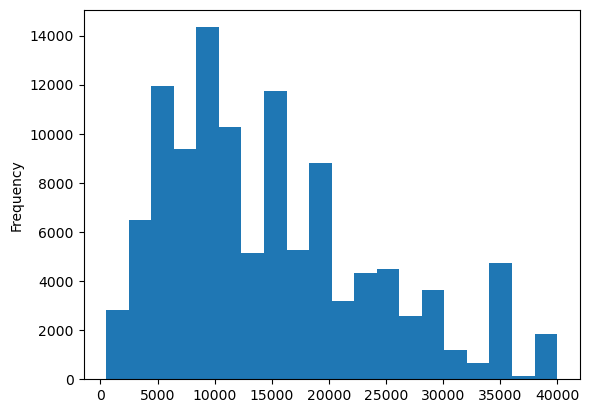

In [13]:
fin['loan_amnt'].plot(kind='hist', bins= 20)

<Axes: ylabel='Density'>

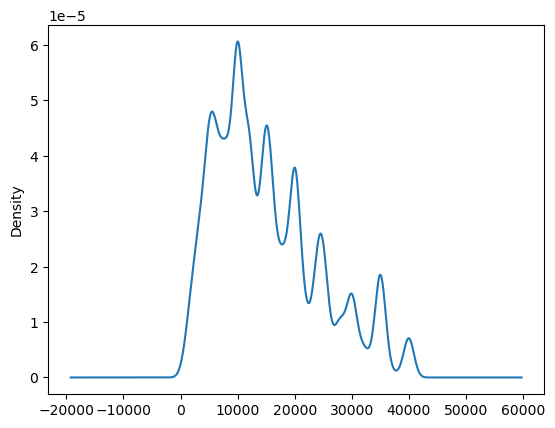

In [14]:
fin['loan_amnt'].plot(kind= 'kde')

<Axes: >

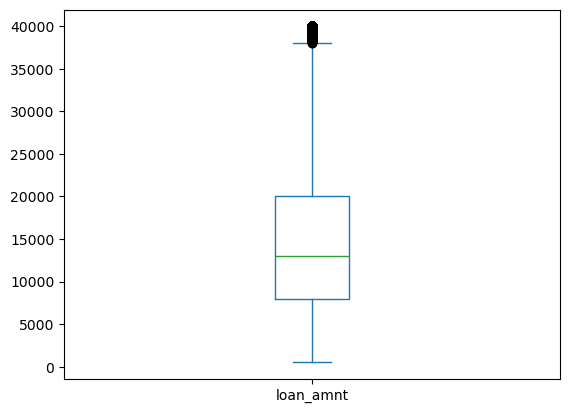

In [15]:
fin['loan_amnt'].plot(kind= 'box')

In [16]:
fin[fin['loan_amnt']>37000]

,loan_amnt,term(months),int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,addr_state,dti,earliest_cr_line,fico_range_low,fico_range_high,open_acc,pub_rec,revol_bal,revol_util,total_acc
1538170,40000.0,60,14.52,941.55,C,C3,10+ years,MORTGAGE,85000.0,Verified,...,PA,25.98,1995-11-01,705.0,709.0,17.0,0.0,18407.0,32.6,24.0
925529,40000.0,36,19.03,1466.85,D,D3,1 year,MORTGAGE,141000.0,Verified,...,TX,12.44,2004-02-01,680.0,684.0,14.0,0.0,22886.0,66.1,24.0
1577932,37800.0,36,9.92,1218.29,B,B2,10+ years,MORTGAGE,160000.0,Verified,...,FL,28.90,1999-03-01,705.0,709.0,26.0,0.0,33094.0,25.0,75.0
874813,40000.0,60,12.13,892.41,B,B5,10+ years,MORTGAGE,105000.0,Source Verified,...,NC,35.25,1999-10-01,695.0,699.0,18.0,0.0,87904.0,69.1,34.0
560241,40000.0,60,13.59,922.25,C,C2,4 years,MORTGAGE,102000.0,Source Verified,...,GA,13.65,1998-12-01,700.0,704.0,18.0,0.0,16356.0,78.2,22.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
585914,40000.0,60,14.08,932.39,C,C3,8 years,MORTGAGE,130000.0,Verified,...,MN,10.49,1998-06-01,710.0,714.0,8.0,0.0,33339.0,68.7,17.0
1557769,40000.0,36,11.98,1328.20,B,B5,9 years,MORTGAGE,148500.0,Verified,...,SC,27.01,1995-05-01,730.0,734.0,30.0,0.0,9249.0,10.7,45.0
767003,39625.0,36,12.73,1329.98,B,B5,6 years,OWN,215000.0,Source Verified,...,NJ,12.78,1997-02-01,690.0,694.0,11.0,0.0,38986.0,65.4,35.0
712578,40000.0,36,11.47,1318.47,B,B5,5 years,OWN,182000.0,Verified,...,AZ,35.05,1993-03-01,740.0,744.0,23.0,0.0,81120.0,55.2,41.0


#### int_rate

 **Conclusions**

- int_rate col contain 0.76 skew here so it is not normal distribution 
- this col have right side skewed data
- int_col contains outliers


In [17]:
fin['int_rate'].describe()

count    113032.000000
mean         13.075182
std           4.808103
min           5.310000
25%           9.490000
50%          12.620000
75%          15.990000
max          30.990000
Name: int_rate, dtype: float64

In [18]:
fin['int_rate'].skew()

np.float64(0.7629866023250008)

<Axes: ylabel='Frequency'>

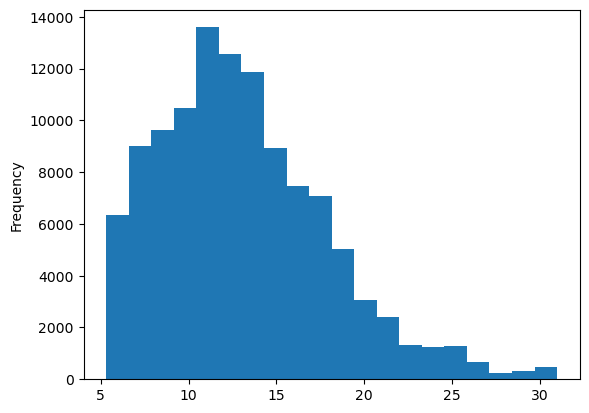

In [19]:
fin['int_rate'].plot(kind='hist',bins=20)

<Axes: ylabel='Density'>

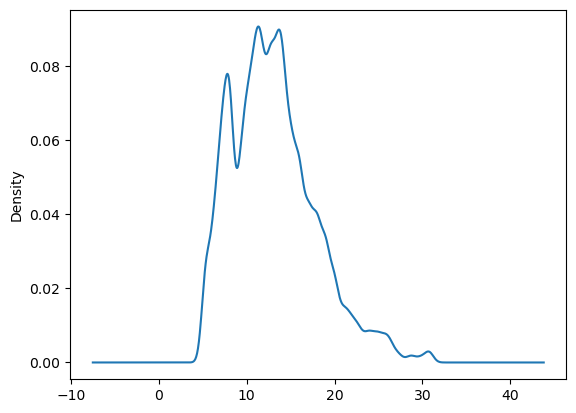

In [20]:
fin['int_rate'].plot(kind='kde')

<Axes: >

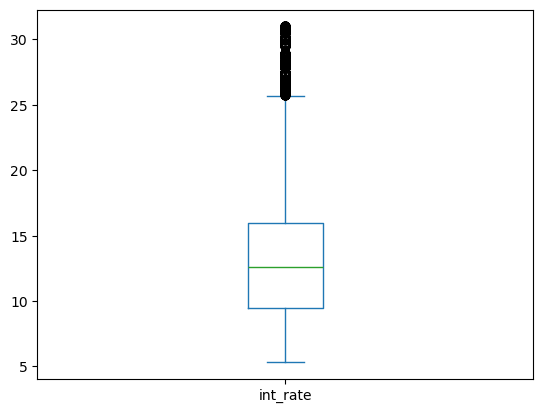

In [21]:
fin['int_rate'].plot(kind='box')

In [22]:
fin[fin['int_rate']> 27]

,loan_amnt,term(months),int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,addr_state,dti,earliest_cr_line,fico_range_low,fico_range_high,open_acc,pub_rec,revol_bal,revol_util,total_acc
551002,18950.0,60,30.65,620.69,F,F4,< 1 year,MORTGAGE,22880.0,Source Verified,...,NE,8.48,2005-04-01,665.0,669.0,5.0,0.0,4041.0,89.8,8.0
1979743,19200.0,60,27.79,595.38,F,F5,4 years,RENT,52000.0,Not Verified,...,NY,34.73,2006-09-01,675.0,679.0,12.0,1.0,22258.0,70.9,24.0
2167883,13200.0,60,30.74,433.09,F,F5,10+ years,OWN,80000.0,Source Verified,...,IN,9.08,2006-06-01,695.0,699.0,21.0,0.0,2922.0,7.0,33.0
613150,30000.0,60,30.17,973.74,F,F3,< 1 year,MORTGAGE,60000.0,Verified,...,IL,3.88,2012-11-01,725.0,729.0,6.0,0.0,5771.0,31.4,7.0
2147792,32000.0,60,29.69,1029.23,F,F2,9 years,MORTGAGE,100000.0,Verified,...,CA,32.49,1991-09-01,670.0,674.0,21.0,1.0,9691.0,26.4,71.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2249570,12000.0,60,27.49,369.95,F,F4,10+ years,MORTGAGE,50000.0,Verified,...,NY,17.83,2001-10-01,705.0,709.0,20.0,0.0,15998.0,36.9,38.0
195874,15000.0,60,27.31,460.82,G,G2,7 years,MORTGAGE,42000.0,Verified,...,NH,25.06,2003-09-01,700.0,704.0,13.0,0.0,8144.0,38.2,19.0
2203247,35000.0,60,28.69,1104.37,F,F1,2 years,MORTGAGE,150000.0,Source Verified,...,WI,12.62,2006-01-01,670.0,674.0,13.0,0.0,28016.0,84.0,19.0
989660,35000.0,60,28.67,1103.95,G,G4,3 years,MORTGAGE,74000.0,Not Verified,...,VA,39.99,1999-10-01,705.0,709.0,18.0,0.0,27105.0,81.4,58.0


#### dti

**Conclusions**

- this column had a lot of outliers so due to this oultlier the dti distribution was not accurate so we had to apply ***Winsorization*** methode to make it outlier free 
- After ***Winsorization*** column distribution appear as log normal distrubustion here

In [23]:
fin['dti'].describe()

count    113032.000000
mean         18.806808
std          14.661394
min           0.000000
25%          11.870000
50%          17.820000
75%          24.470000
max         999.000000
Name: dti, dtype: float64

In [24]:
fin['dti'].skew()

np.float64(29.68526835610812)

<Axes: ylabel='Frequency'>

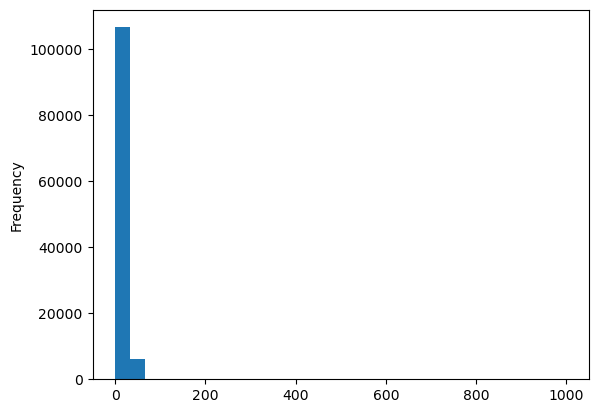

In [25]:
fin['dti'].plot(kind='hist',bins=30)

#### Note: 
***dti column contain high amount of outlier so here we have to apply a winsorization or percentile methode to exclude oulier effect and to  find real distribution for dti column value***

#### Winsorization Process

In [26]:
upper_threshold = fin['dti'].quantile(0.99)
upper_threshold

np.float64(42.41690000000003)

In [27]:
#applying winsorization on dti column
fin['win_dti'] = np.where(fin['dti']>= upper_threshold,upper_threshold,fin['dti'])

In [28]:
fin['win_dti'].describe()

count    113032.000000
mean         18.443976
std           8.822120
min           0.000000
25%          11.870000
50%          17.820000
75%          24.470000
max          42.416900
Name: win_dti, dtype: float64

In [29]:
fin['win_dti'].skew()

np.float64(0.3277704034350472)

In [30]:
fin

,loan_amnt,term(months),int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,dti,earliest_cr_line,fico_range_low,fico_range_high,open_acc,pub_rec,revol_bal,revol_util,total_acc,win_dti
2210277,19600.0,60,17.99,497.61,D,D2,4 years,MORTGAGE,140400.0,Not Verified,...,6.51,2013-06-01,675.0,679.0,7.0,0.0,10779.0,61.2,8.0,6.51
1011112,10000.0,36,12.99,336.90,C,C2,3 years,RENT,44000.0,Source Verified,...,21.49,1995-03-01,690.0,694.0,12.0,0.0,10065.0,64.1,16.0,21.49
2012160,7000.0,36,15.59,244.69,C,C5,6 years,RENT,43000.0,Not Verified,...,26.65,2012-05-01,660.0,664.0,5.0,0.0,16404.0,78.1,7.0,26.65
1682998,12000.0,60,25.49,355.68,E,E4,10+ years,OWN,45000.0,Not Verified,...,31.36,2004-04-01,705.0,709.0,11.0,0.0,17506.0,42.0,25.0,31.36
1538170,40000.0,60,14.52,941.55,C,C3,10+ years,MORTGAGE,85000.0,Verified,...,25.98,1995-11-01,705.0,709.0,17.0,0.0,18407.0,32.6,24.0,25.98
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1496125,21000.0,60,18.45,538.42,D,D2,2 years,RENT,50000.0,Verified,...,16.85,2014-02-01,665.0,669.0,7.0,0.0,6812.0,42.3,9.0,16.85
1354794,10000.0,36,15.02,346.76,C,C3,3 years,RENT,29000.0,Not Verified,...,15.89,2014-04-01,710.0,714.0,4.0,0.0,5857.0,79.1,4.0,15.89
592598,20000.0,36,7.97,626.46,A,A5,10+ years,RENT,180000.0,Verified,...,10.37,1988-05-01,695.0,699.0,12.0,0.0,5090.0,18.6,32.0,10.37
336507,15000.0,36,6.92,462.61,A,A4,7 years,RENT,120000.0,Not Verified,...,13.15,1994-11-01,775.0,779.0,8.0,0.0,2352.0,4.5,20.0,13.15


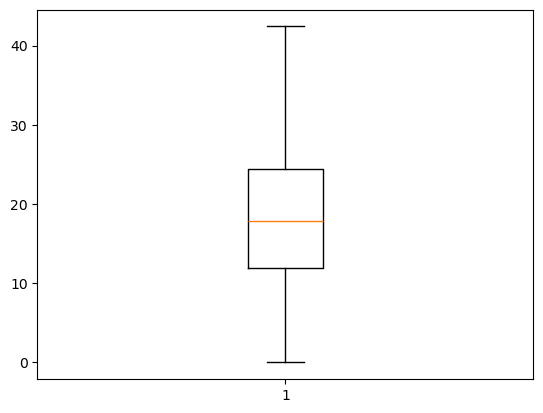

In [31]:
plt.boxplot(fin['win_dti'])
plt.show()

<Axes: ylabel='Frequency'>

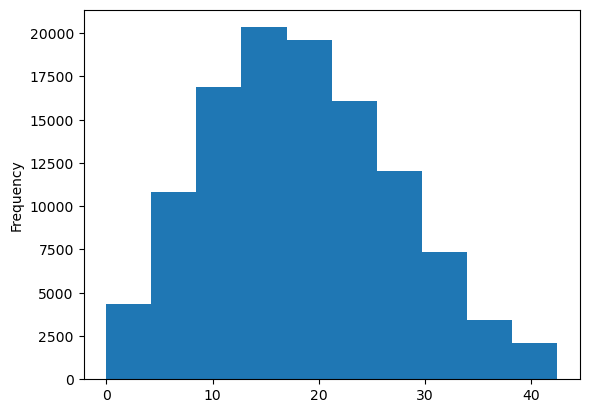

In [32]:
fin['win_dti'].plot(kind='hist')

<Axes: ylabel='Density'>

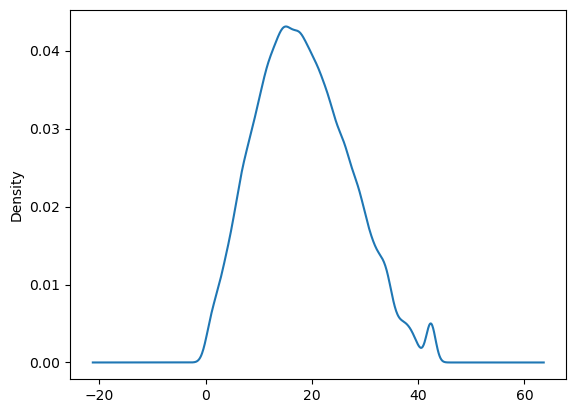

In [33]:
fin['win_dti'].plot(kind='kde')

#### fico_range_low

**Conclusions**

- 

In [34]:
fin['fico_range_low'].describe()

count    113032.000000
mean        698.642464
std          33.116370
min         640.000000
25%         675.000000
50%         690.000000
75%         715.000000
max         845.000000
Name: fico_range_low, dtype: float64

In [35]:
fin['fico_range_low'].skew()

np.float64(1.2047005075054227)

<Axes: ylabel='Frequency'>

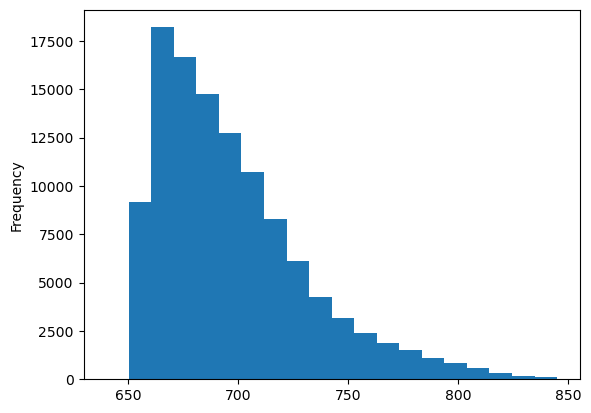

In [36]:
fin['fico_range_low'].plot(kind='hist', bins=20)

<Axes: ylabel='Density'>

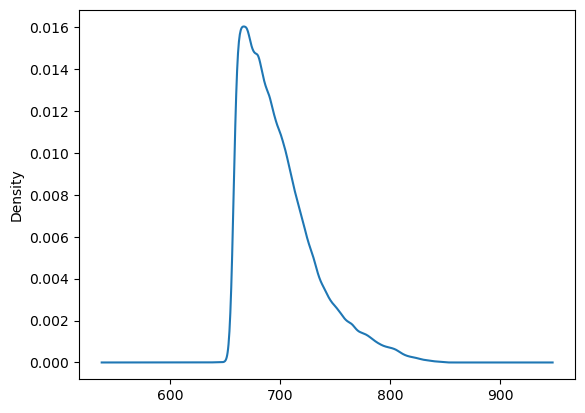

In [37]:
fin['fico_range_low'].plot(kind='kde')

<Axes: >

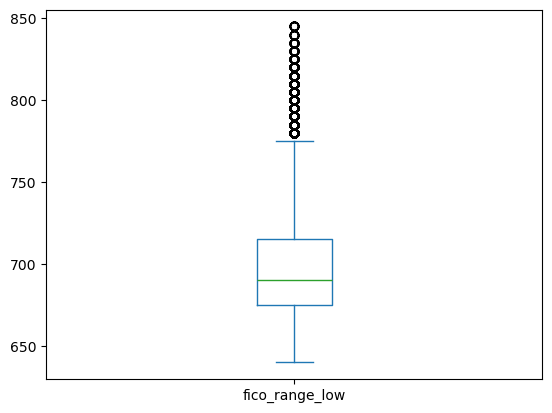

In [38]:
fin['fico_range_low'].plot(kind='box')

In [39]:
fin[fin['fico_range_low'] > 775]

,loan_amnt,term(months),int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,dti,earliest_cr_line,fico_range_low,fico_range_high,open_acc,pub_rec,revol_bal,revol_util,total_acc,win_dti
1423761,3000.0,36,8.81,95.14,A,A5,8 years,OWN,61000.0,Not Verified,...,32.23,2003-07-01,780.0,784.0,6.0,0.0,14141.0,33.4,45.0,32.23
2121743,19000.0,36,5.32,572.19,A,A1,5 years,RENT,119000.0,Verified,...,11.02,2010-09-01,800.0,804.0,15.0,0.0,0.0,0.0,23.0,11.02
830700,35000.0,36,6.67,1075.43,A,A2,3 years,RENT,145000.0,Source Verified,...,22.23,2002-02-01,795.0,799.0,18.0,0.0,26119.0,12.1,35.0,22.23
1652766,1000.0,36,8.59,31.62,A,A4,1 year,MORTGAGE,120000.0,Not Verified,...,12.05,1992-12-01,805.0,809.0,4.0,0.0,269726.0,4.3,13.0,12.05
1019629,20000.0,36,5.32,602.30,A,A1,10+ years,MORTGAGE,73000.0,Not Verified,...,15.57,2001-02-01,815.0,819.0,14.0,0.0,9660.0,13.6,28.0,15.57
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111896,35000.0,60,13.99,814.21,C,C4,10+ years,MORTGAGE,95000.0,Source Verified,...,24.23,1985-08-01,780.0,784.0,28.0,0.0,5470.0,11.8,33.0,24.23
1369766,20000.0,60,12.98,454.86,B,B5,Unknown,MORTGAGE,72000.0,Verified,...,24.93,1987-12-01,795.0,799.0,17.0,0.0,5895.0,12.0,38.0,24.93
1074303,10000.0,36,6.49,306.45,A,A2,< 1 year,MORTGAGE,40000.0,Not Verified,...,19.94,1996-11-01,790.0,794.0,13.0,0.0,9528.0,9.2,22.0,19.94
1027363,12500.0,36,5.32,376.44,A,A1,< 1 year,MORTGAGE,80000.0,Not Verified,...,18.71,2003-11-01,805.0,809.0,9.0,0.0,1304.0,5.3,12.0,18.71


#### fico_rate_high

**Conclusion**

- 

In [40]:
fin['fico_range_high'].describe()

count    113032.000000
mean        702.642703
std          33.117430
min         644.000000
25%         679.000000
50%         694.000000
75%         719.000000
max         850.000000
Name: fico_range_high, dtype: float64

In [41]:
fin['fico_range_high'].skew()

np.float64(1.2049887922353522)

<Axes: ylabel='Frequency'>

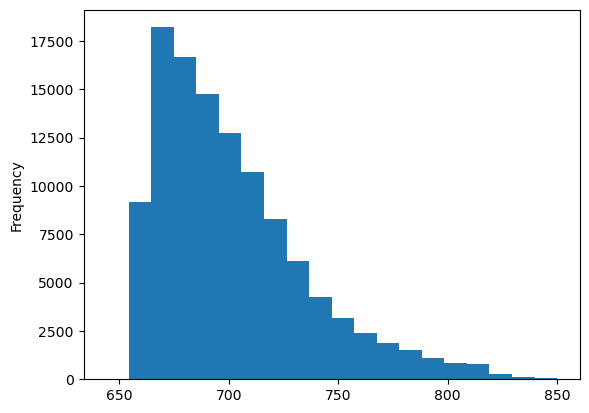

In [42]:
fin['fico_range_high'].plot(kind='hist',bins=20)

<Axes: ylabel='Density'>

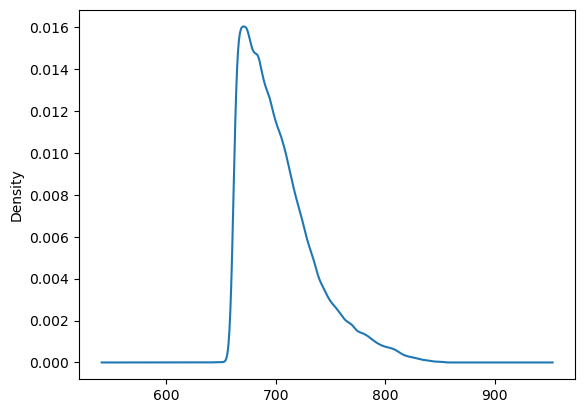

In [43]:
fin['fico_range_high'].plot(kind='kde')

<Axes: >

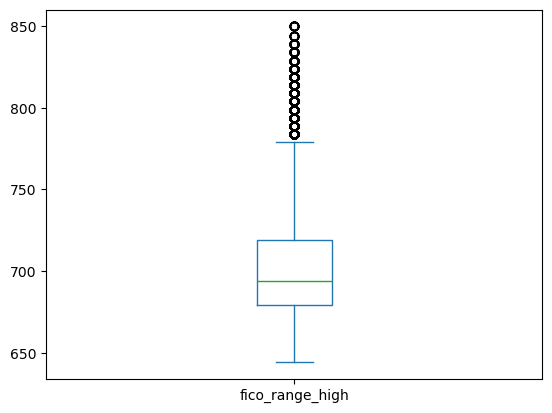

In [44]:
fin['fico_range_high'].plot(kind='box')

In [45]:
fin[fin['fico_range_high'] > 775]

,loan_amnt,term(months),int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,dti,earliest_cr_line,fico_range_low,fico_range_high,open_acc,pub_rec,revol_bal,revol_util,total_acc,win_dti
1423761,3000.0,36,8.81,95.14,A,A5,8 years,OWN,61000.0,Not Verified,...,32.23,2003-07-01,780.0,784.0,6.0,0.0,14141.0,33.4,45.0,32.23
2121743,19000.0,36,5.32,572.19,A,A1,5 years,RENT,119000.0,Verified,...,11.02,2010-09-01,800.0,804.0,15.0,0.0,0.0,0.0,23.0,11.02
830700,35000.0,36,6.67,1075.43,A,A2,3 years,RENT,145000.0,Source Verified,...,22.23,2002-02-01,795.0,799.0,18.0,0.0,26119.0,12.1,35.0,22.23
1652766,1000.0,36,8.59,31.62,A,A4,1 year,MORTGAGE,120000.0,Not Verified,...,12.05,1992-12-01,805.0,809.0,4.0,0.0,269726.0,4.3,13.0,12.05
1019629,20000.0,36,5.32,602.30,A,A1,10+ years,MORTGAGE,73000.0,Not Verified,...,15.57,2001-02-01,815.0,819.0,14.0,0.0,9660.0,13.6,28.0,15.57
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1369766,20000.0,60,12.98,454.86,B,B5,Unknown,MORTGAGE,72000.0,Verified,...,24.93,1987-12-01,795.0,799.0,17.0,0.0,5895.0,12.0,38.0,24.93
1074303,10000.0,36,6.49,306.45,A,A2,< 1 year,MORTGAGE,40000.0,Not Verified,...,19.94,1996-11-01,790.0,794.0,13.0,0.0,9528.0,9.2,22.0,19.94
1027363,12500.0,36,5.32,376.44,A,A1,< 1 year,MORTGAGE,80000.0,Not Verified,...,18.71,2003-11-01,805.0,809.0,9.0,0.0,1304.0,5.3,12.0,18.71
274112,20000.0,60,7.89,404.48,A,A5,10+ years,MORTGAGE,103000.0,Source Verified,...,12.83,1999-03-01,780.0,784.0,12.0,0.0,18849.0,16.1,24.0,12.83


#### annual_inc

**Conclusion**

- 

In [46]:
fin['annual_inc'].describe()

count    1.130320e+05
mean     7.749744e+04
std      5.973456e+04
min      0.000000e+00
25%      4.600000e+04
50%      6.500000e+04
75%      9.300000e+04
max      5.214756e+06
Name: annual_inc, dtype: float64

In [47]:
fin['annual_inc'].skew()

np.float64(16.529110483199865)

<Axes: ylabel='Frequency'>

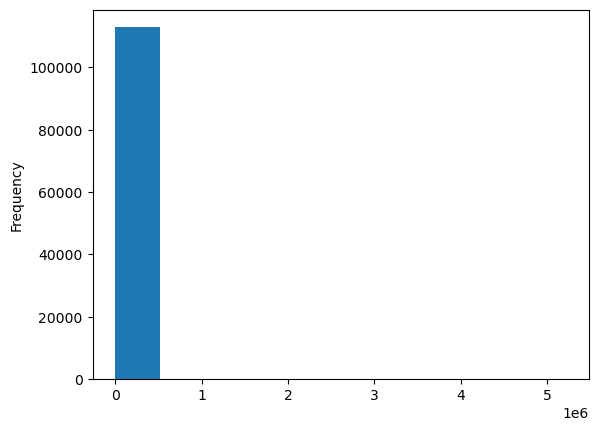

In [48]:
fin['annual_inc'].plot(kind='hist')

#### Winsorization 

**Note** :

In [49]:
upper_limit = fin['annual_inc'].quantile(0.99)
upper_limit

np.float64(270000.0)

In [50]:
fin['win_annual_inc'] = np.where(fin['annual_inc']>upper_limit,upper_limit,fin['annual_inc'])

In [51]:
fin['win_annual_inc'].describe()

count    113032.000000
mean      76100.992968
std       44558.201447
min           0.000000
25%       46000.000000
50%       65000.000000
75%       93000.000000
max      270000.000000
Name: win_annual_inc, dtype: float64

<Axes: >

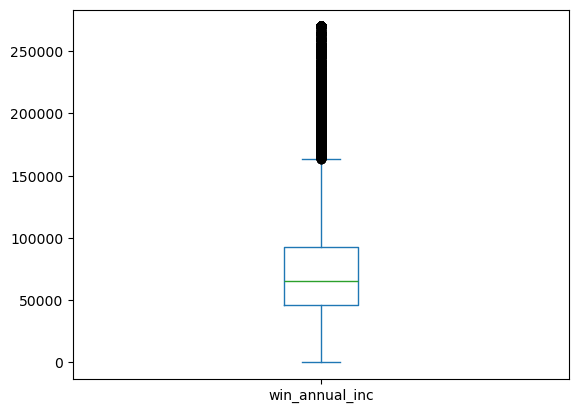

In [52]:
fin['win_annual_inc'].plot(kind='box')

<Axes: ylabel='Density'>

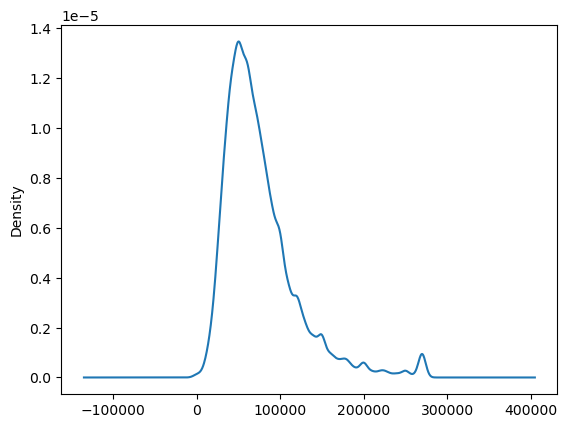

In [53]:
fin['win_annual_inc'].plot(kind='kde')

### Univariate Analysis on Tier 1 Categorical columns

#### loan_status

**Conclusions**

- 

In [54]:
fin['loan_status'].value_counts()

loan_status
Fully Paid                                             53864
Current                                                43877
Charged Off                                            13444
Late (31-120 days)                                      1074
In Grace Period                                          425
Late (16-30 days)                                        224
Does not meet the credit policy. Status:Fully Paid        90
Does not meet the credit policy. Status:Charged Off       33
Default                                                    1
Name: count, dtype: int64

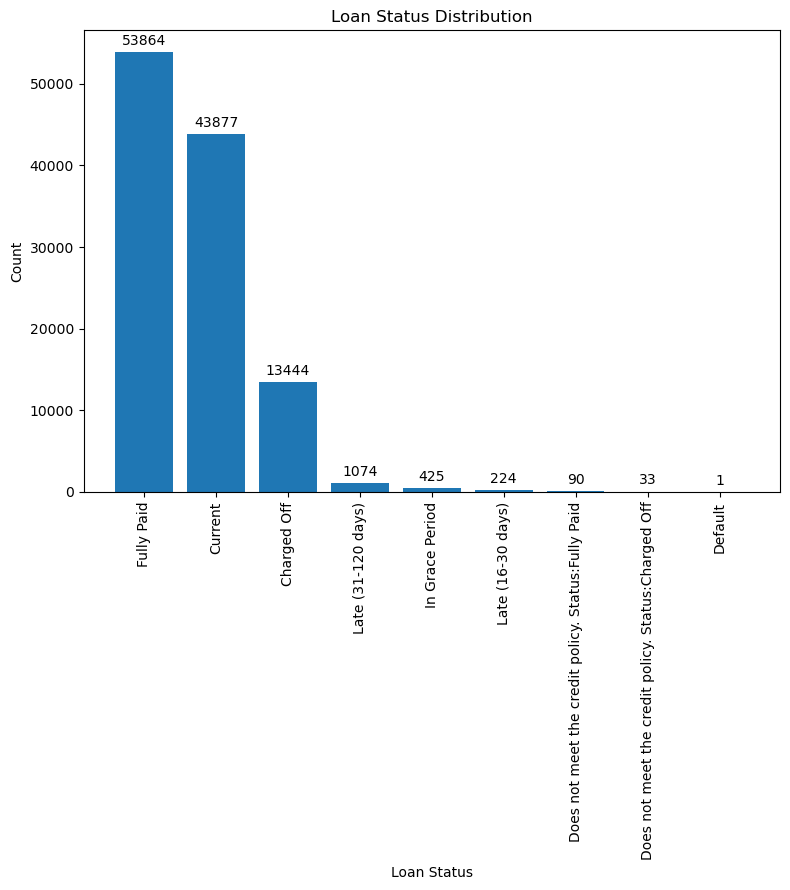

In [55]:
loan_counts = fin['loan_status'].value_counts()

fig, ax = plt.subplots(figsize=(8,9))

bars = ax.bar(loan_counts.index, loan_counts.values)

ax.bar_label(bars, fmt='%d', padding=3)
ax.set_title('Loan Status Distribution')
ax.set_xlabel('Loan Status')
ax.set_ylabel('Count')

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

#### grade

**Conclusions**

- 

In [56]:
grade_count = fin['grade'].value_counts()
grade_count

grade
B    33302
C    32616
A    21600
D    16195
E     6700
F     2032
G      587
Name: count, dtype: int64

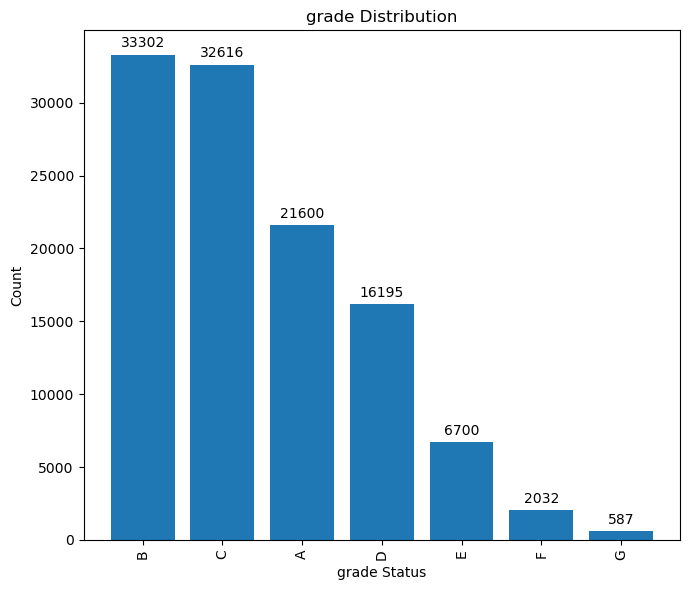

In [57]:
fig,ax = plt.subplots(figsize=(7,6))

bars = ax.bar(grade_count.index, grade_count.values)

ax.bar_label(bars, fmt='%d', padding=3)
ax.set_title('grade Distribution')
ax.set_xlabel('grade Status')
ax.set_ylabel('Count')

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

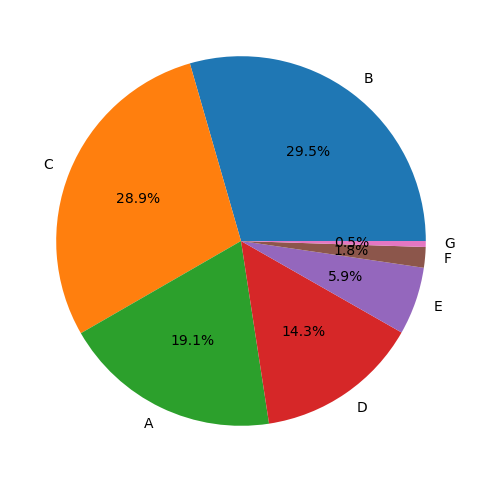

In [58]:
plt.figure(figsize=(9,6))
plt.pie(grade_count,labels= grade_count.index,autopct= '%0.1f%%')
plt.show()

#### sub_grade

**Conclusions**

- 

In [59]:
fin['sub_grade'].value_counts().size

35

In [60]:
sub_g_count=fin['sub_grade'].value_counts()
sub_g_count


sub_grade
C1    7289
B5    7038
B4    7002
B3    6703
C2    6553
C3    6487
C4    6329
B2    6287
B1    6272
C5    5958
A5    5383
A4    4712
A1    4389
D1    4055
A3    3613
D2    3585
A2    3503
D3    3286
D4    2922
D5    2347
E1    1638
E2    1475
E3    1329
E5    1152
E4    1106
F1     638
F2     451
F3     362
F4     320
F5     261
G1     213
G2     115
G3     108
G5      81
G4      70
Name: count, dtype: int64

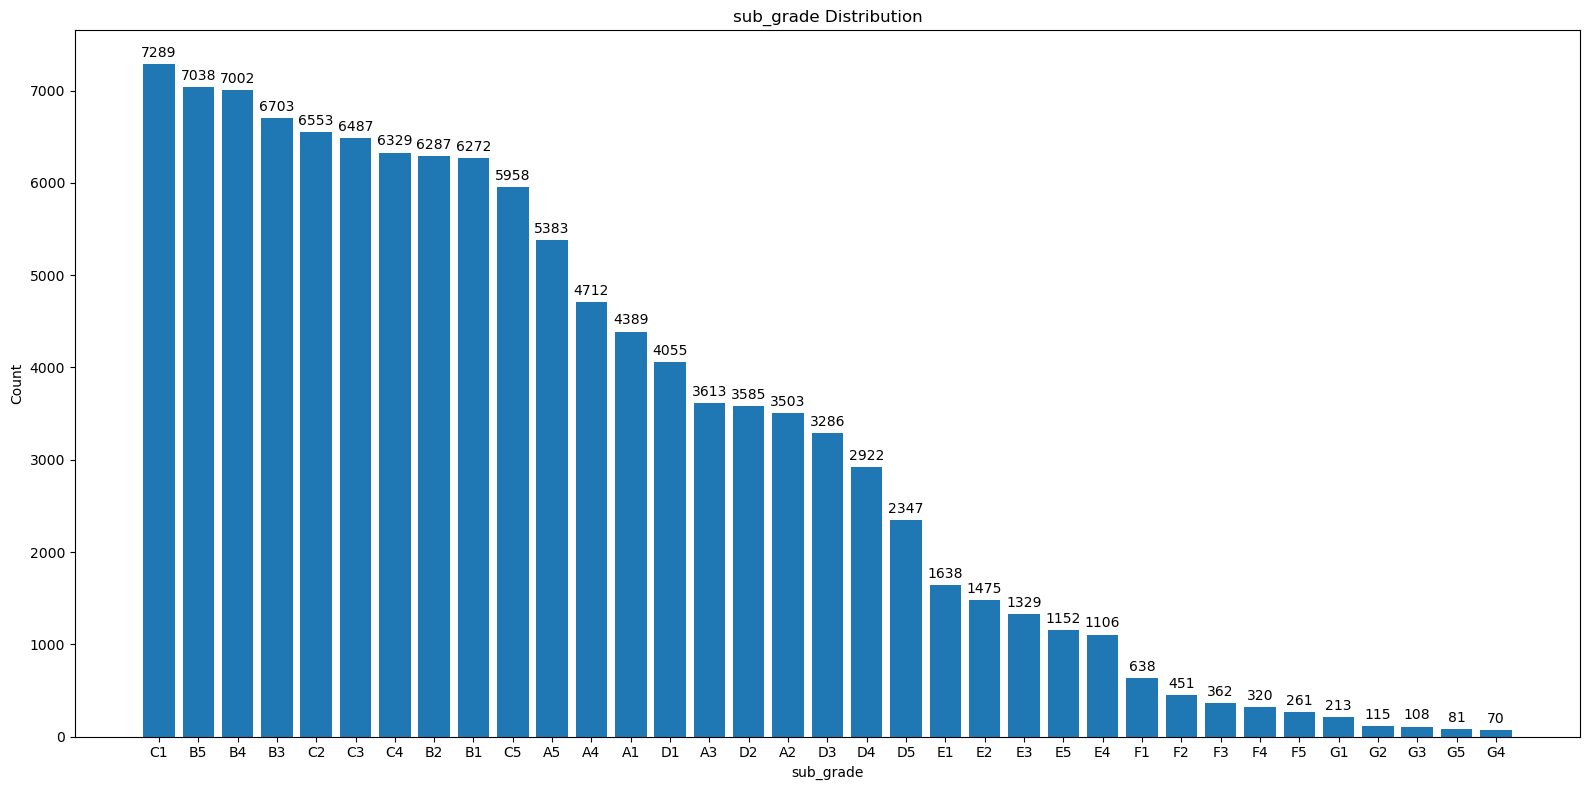

In [61]:
fig, ax = plt.subplots(figsize=(16,8))

bars = ax.bar(sub_g_count.index, sub_g_count.values)

ax.bar_label(bars, fmt='%d', padding=3)
ax.set_title('sub_grade Distribution')
ax.set_xlabel('sub_grade')
ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

#### Tier 2 Columns 

- #### 2nd most effective columns
    - `purpose`
    - `home_ownership`
    - `emp_length`
    - `term(months)`
    - `verification_status`

### Univariate Analysis on Tier 2 Numerical columns

In [62]:
fin[['purpose','home_ownership','emp_length','term(months)','verification_status']]

,purpose,home_ownership,emp_length,term(months),verification_status
2210277,debt_consolidation,MORTGAGE,4 years,60,Not Verified
1011112,debt_consolidation,RENT,3 years,36,Source Verified
2012160,debt_consolidation,RENT,6 years,36,Not Verified
1682998,credit_card,OWN,10+ years,60,Not Verified
1538170,debt_consolidation,MORTGAGE,10+ years,60,Verified
...,...,...,...,...,...
1496125,credit_card,RENT,2 years,60,Verified
1354794,debt_consolidation,RENT,3 years,36,Not Verified
592598,debt_consolidation,RENT,10+ years,36,Verified
336507,other,RENT,7 years,36,Not Verified


#### purpose

**Conclusions**

- 

In [63]:
purpose_bar = fin['purpose'].value_counts()
purpose_bar

purpose
debt_consolidation    63855
credit_card           25935
home_improvement       7518
other                  7022
major_purchase         2551
medical                1406
small_business         1212
car                    1158
moving                  750
vacation                737
house                   688
wedding                 117
renewable_energy         65
educational              18
Name: count, dtype: int64

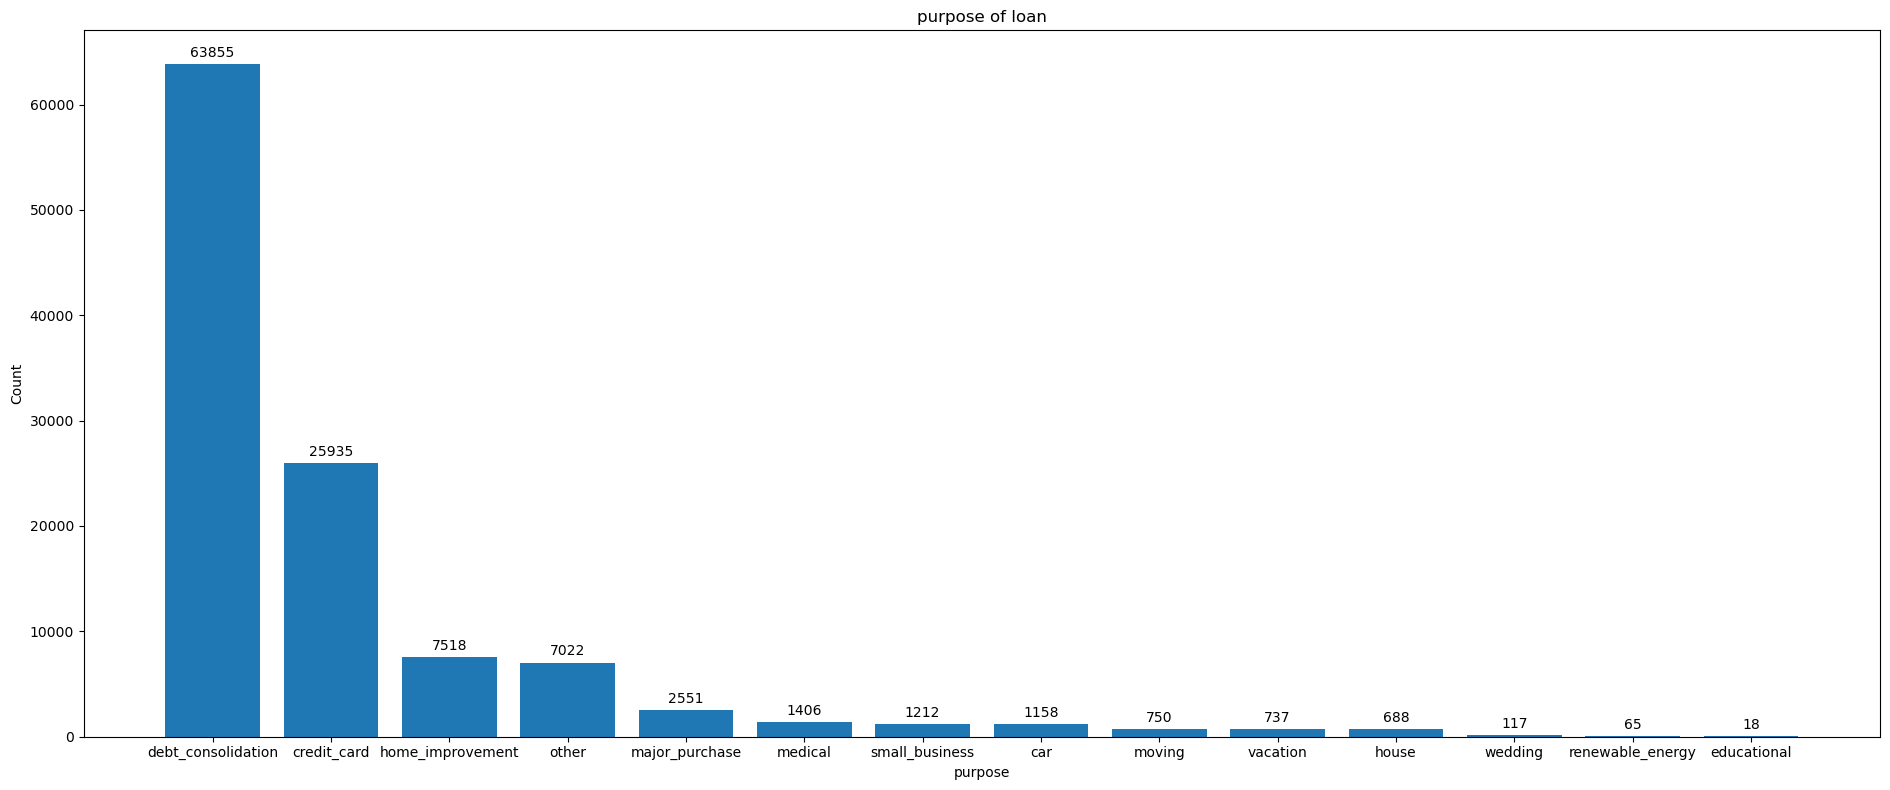

In [64]:
fig, ax = plt.subplots(figsize=(19,8))

bars = ax.bar(purpose_bar.index, purpose_bar.values)

ax.bar_label(bars, fmt='%d', padding=3)
ax.set_title('purpose of loan')
ax.set_xlabel('purpose')
ax.set_ylabel('Count')

plt.tight_layout()
plt.show()


#### home_ownership

**Counclusions**

- 

In [65]:
home = fin['home_ownership'].value_counts()
home

home_ownership
MORTGAGE    55570
RENT        44706
OWN         12685
ANY            53
OTHER          16
NONE            2
Name: count, dtype: int64

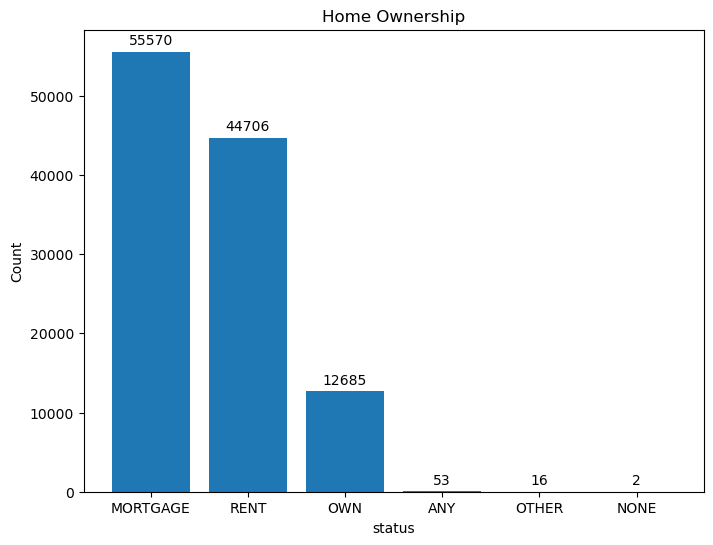

In [66]:
fig, ax = plt.subplots(figsize=(8,6))

bars = ax.bar(home.index, home.values)

ax.bar_label(bars, fmt='%d', padding=3)
ax.set_title('Home Ownership')
ax.set_xlabel('status')
ax.set_ylabel('Count')

plt.show()

<Axes: ylabel='count'>

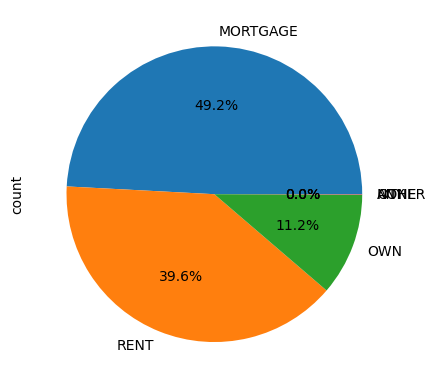

In [67]:
fin['home_ownership'].value_counts().plot(kind='pie',autopct = '%0.1f%%')

#### emp_length

**Conclusion**

- 

In [68]:
fin['emp_length'].value_counts()

emp_length
10+ years    37109
2 years      10150
< 1 year      9550
3 years       9094
1 year        7414
Unknown       7392
5 years       6981
4 years       6961
6 years       5100
7 years       4734
8 years       4658
9 years       3889
Name: count, dtype: int64

In [69]:
emp_len = fin['emp_length'].value_counts()

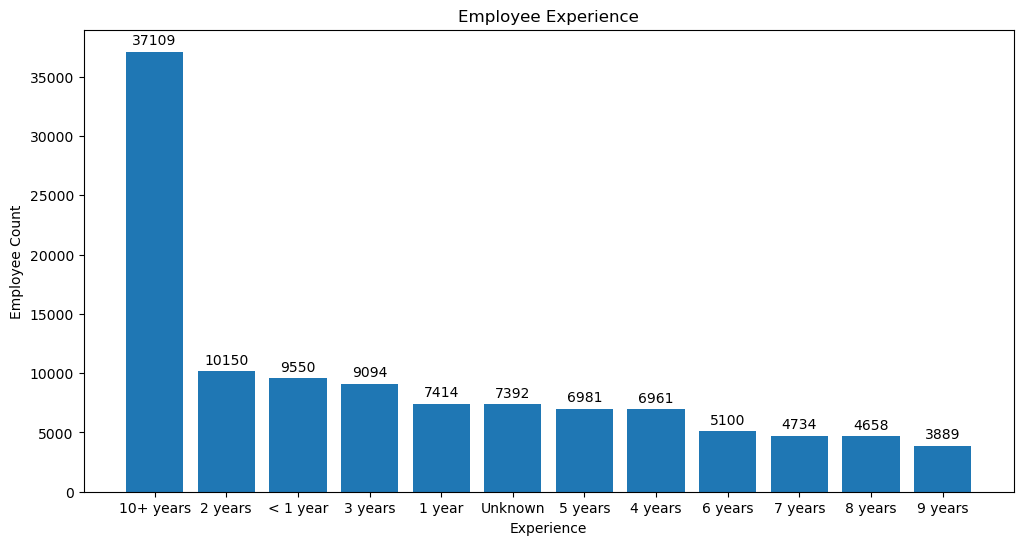

In [70]:
fig, ax = plt.subplots(figsize=(12,6))

bars = ax.bar(emp_len.index, emp_len.values)

ax.bar_label(bars, fmt='%d', padding=3)
ax.set_title('Employee Experience')
ax.set_xlabel('Experience')
ax.set_ylabel('Employee Count')

plt.show()

#### term(months)

**Conclusion**

- 

In [71]:
fin['term(months)'].value_counts()

term(months)
36    80489
60    32543
Name: count, dtype: int64

<Axes: ylabel='count'>

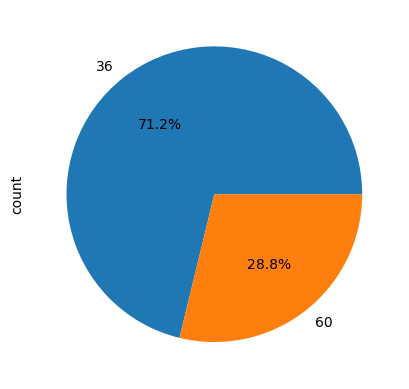

In [72]:
fin['term(months)'].value_counts().plot(kind='pie',autopct= '%0.1f%%')

#### verification_status

**Conclusion**

- 

In [73]:
fin['verification_status'].value_counts()

verification_status
Source Verified    44399
Not Verified       37100
Verified           31533
Name: count, dtype: int64

<Axes: ylabel='count'>

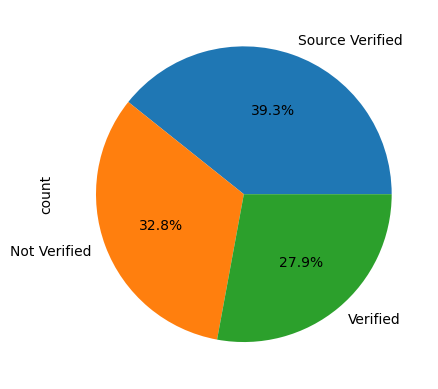

In [74]:
fin['verification_status'].value_counts().plot(kind='pie',autopct='%0.1f%%')

### Bivariate Analysis

- int_rate vs loan_status → box plot by status
- dti vs loan_status → box plot by status  
- fico_range_low vs loan_status → box plot by status
- annual_inc vs loan_status → box plot by status
- loan_amnt vs loan_status → box plot by status

In [75]:
fin.head()

,loan_amnt,term(months),int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,earliest_cr_line,fico_range_low,fico_range_high,open_acc,pub_rec,revol_bal,revol_util,total_acc,win_dti,win_annual_inc
2210277,19600.0,60,17.99,497.61,D,D2,4 years,MORTGAGE,140400.0,Not Verified,...,2013-06-01,675.0,679.0,7.0,0.0,10779.0,61.2,8.0,6.51,140400.0
1011112,10000.0,36,12.99,336.90,C,C2,3 years,RENT,44000.0,Source Verified,...,1995-03-01,690.0,694.0,12.0,0.0,10065.0,64.1,16.0,21.49,44000.0
2012160,7000.0,36,15.59,244.69,C,C5,6 years,RENT,43000.0,Not Verified,...,2012-05-01,660.0,664.0,5.0,0.0,16404.0,78.1,7.0,26.65,43000.0
1682998,12000.0,60,25.49,355.68,E,E4,10+ years,OWN,45000.0,Not Verified,...,2004-04-01,705.0,709.0,11.0,0.0,17506.0,42.0,25.0,31.36,45000.0
1538170,40000.0,60,14.52,941.55,C,C3,10+ years,MORTGAGE,85000.0,Verified,...,1995-11-01,705.0,709.0,17.0,0.0,18407.0,32.6,24.0,25.98,85000.0


#### int_rate vs loan_status

**Conclusions**

- 47% of loans are Fully Paid. where only 40 are Charged Off (defaulted). This class imbalance is important — any model built on this data will need to account for it.

In [76]:
status_counts = fin_full['loan_status'].value_counts() 
status_counts

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1962
Does not meet the credit policy. Status:Charged Off        758
Default                                                     40
Name: count, dtype: int64

In [77]:
status_pct = fin_full['loan_status'].value_counts(normalize=True) * 100
status_pct.round(2)

loan_status
Fully Paid                                             47.63
Current                                                38.85
Charged Off                                            11.88
Late (31-120 days)                                      0.95
In Grace Period                                         0.37
Late (16-30 days)                                       0.19
Does not meet the credit policy. Status:Fully Paid      0.09
Does not meet the credit policy. Status:Charged Off     0.03
Default                                                 0.00
Name: proportion, dtype: float64

**loan_status column contain long string value that can be a headache in the future in SQL analysis or in Upcoming Analysis(Multivariate and Statistics) so i am here changing there value from**
- #does not meet the credit policy. status: Charged Off = `NCP Charged Off` 
- #does not meet the credit policy. status: Fully Paid = `NCP Fully Paid`

In [78]:
fin['loan_status'] = fin['loan_status'].str.replace('Does not meet the credit policy. Status:','NCP ')

In [79]:
fin['loan_status'].value_counts()

loan_status
Fully Paid            53864
Current               43877
Charged Off           13444
Late (31-120 days)     1074
In Grace Period         425
Late (16-30 days)       224
NCP Fully Paid           90
NCP Charged Off          33
Default                   1
Name: count, dtype: int64

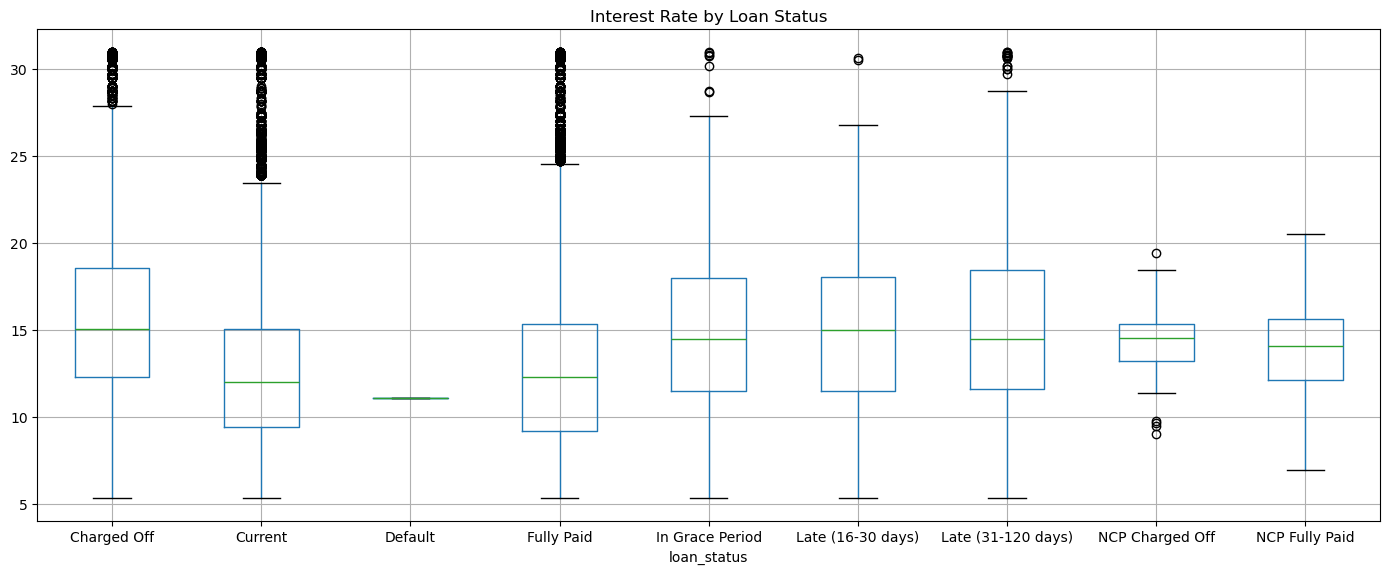

In [80]:
fin.boxplot(column='int_rate', by='loan_status', figsize=(14, 6))
plt.title('Interest Rate by Loan Status')
plt.suptitle('')  
plt.tight_layout()
plt.show()

#### dti vs loan_status → box plot by status

- Conclusion

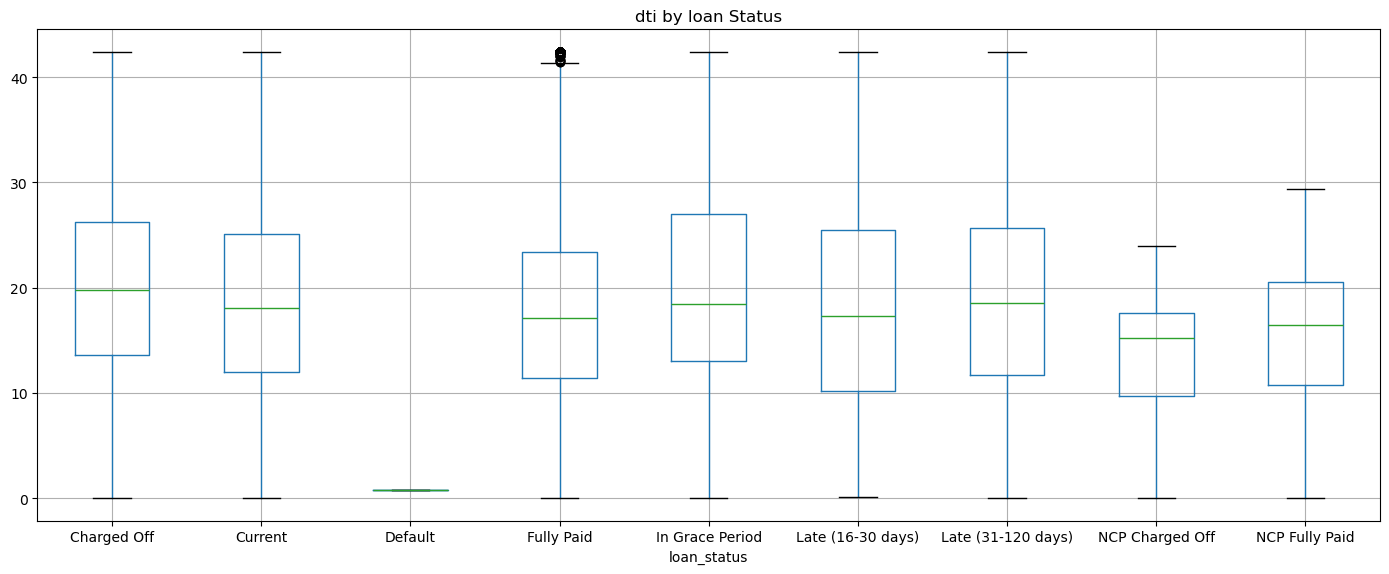

In [81]:
# win_dti is a winsorization applied dti column that shows outliers excluded dti values
fin.boxplot(column='win_dti', by='loan_status', figsize=(14,6))
plt.title('dti by loan Status')
plt.suptitle('')
plt.tight_layout()
plt.show()

#### fico_range_low vs loan_status → box plot by status

**Conclusion**

- 

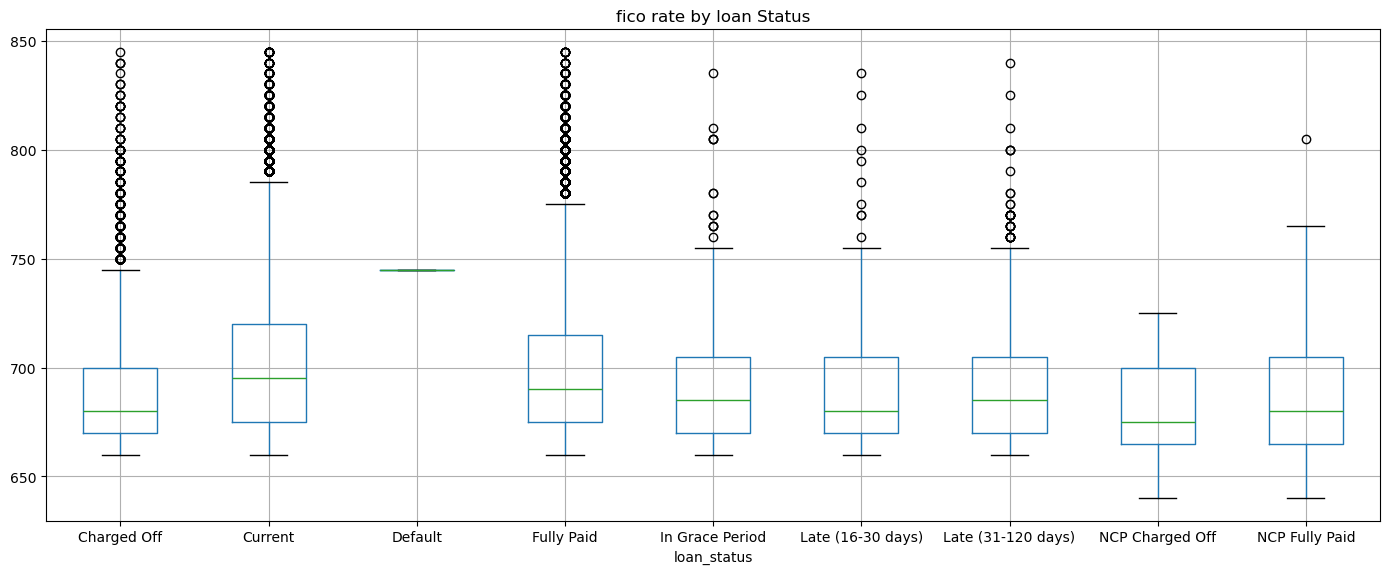

In [82]:
fin.boxplot(column='fico_range_low', by='loan_status', figsize=(14,6))
plt.title('fico rate by loan Status')
plt.suptitle('')
plt.tight_layout()
plt.show()

#### annual_inc vs loan_status → box plot by status

**Conclusion**

- 

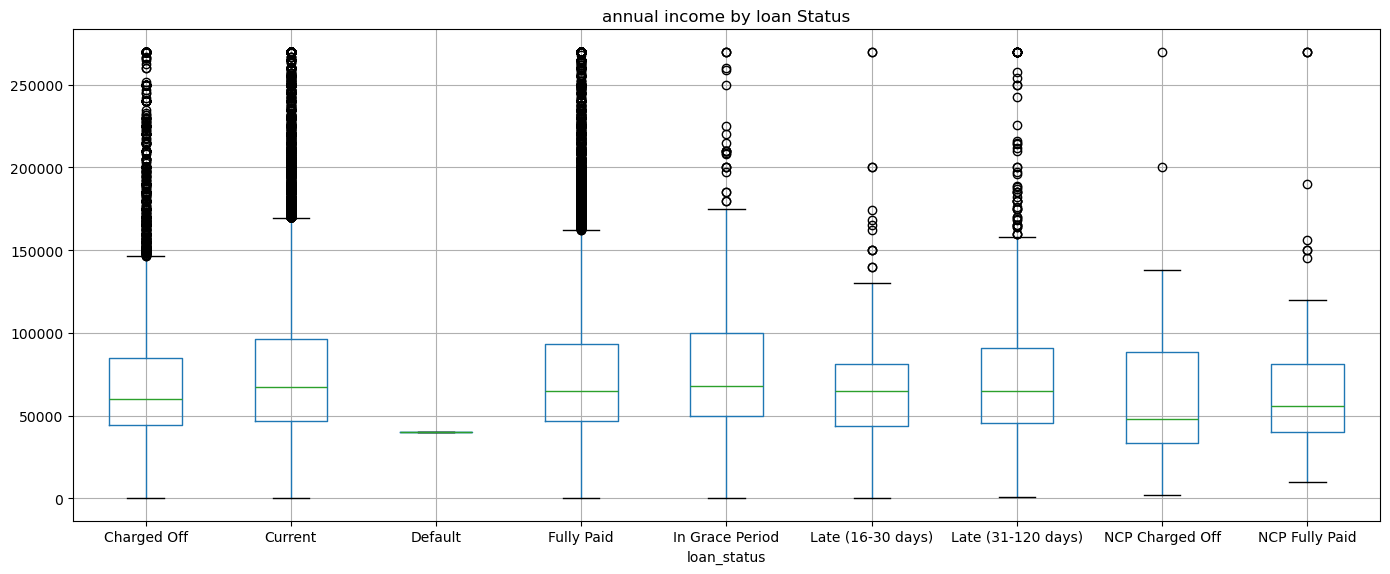

In [83]:
fin.boxplot(column='win_annual_inc', by='loan_status', figsize=(14,6))
plt.title('annual income by loan Status')
plt.suptitle('')
plt.tight_layout()
plt.show()

#### loan_amnt vs loan_status → box plot by status

**Conclusions**

- 

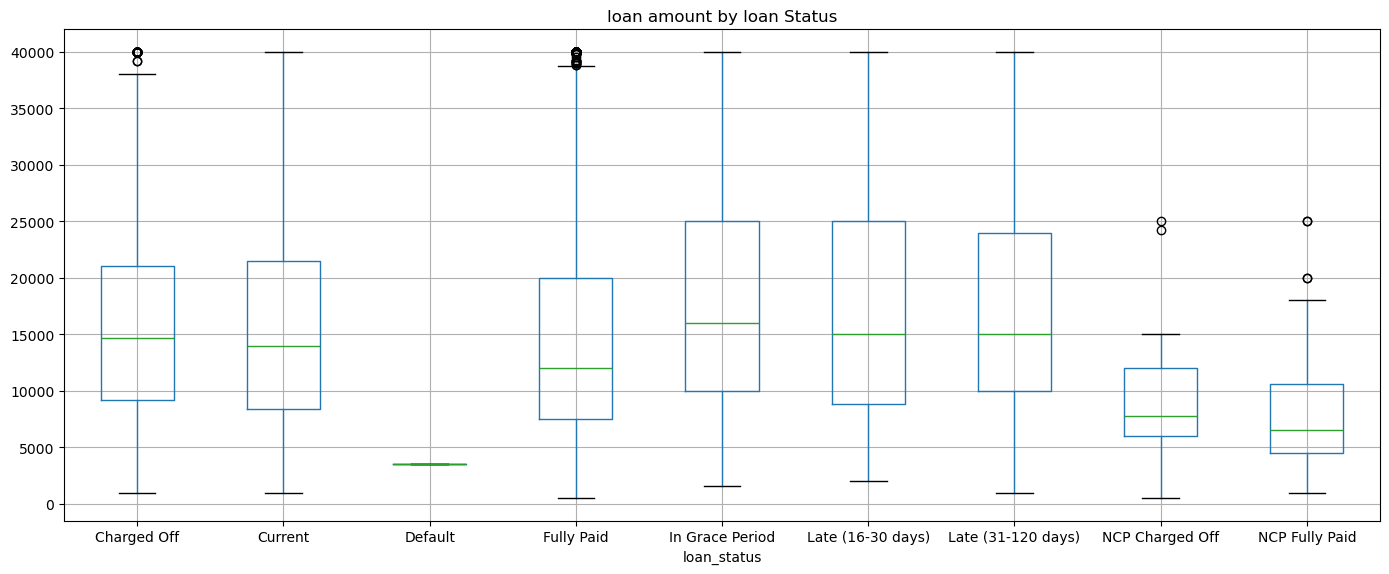

In [84]:
fin.boxplot(column='loan_amnt', by='loan_status', figsize=(14,6))
plt.title('loan amount by loan Status')
plt.suptitle('')
plt.tight_layout()
plt.show()

- grade vs loan_status → bar chart (default rate by grade)
- purpose vs loan_status → bar chart
- home_ownership vs loan_status → bar chart
- term vs loan_status → bar chart
- verification_status vs loan_status → bar chart
- emp_length vs loan_status → bar chart

#### grade vs loan_status → bar chart (default rate by grade)

In [88]:
(pd.crosstab(fin['loan_status'],fin['grade'],normalize='columns')*100).round(3)

grade,A,B,C,D,E,F,G
loan_status,,,,,,,
Charged Off,3.319,7.942,13.193,18.839,26.761,35.236,37.308
Current,45.213,39.529,39.309,35.060,28.313,20.866,21.635
Default,0.000,0.003,0.000,0.000,0.000,0.000,0.000
Fully Paid,50.921,51.297,45.453,43.476,42.612,41.142,38.330
In Grace Period,0.144,0.276,0.503,0.580,0.433,0.443,1.022
Late (16-30 days),0.074,0.159,0.224,0.414,0.179,0.148,0.000
Late (31-120 days),0.310,0.739,1.223,1.439,1.358,1.575,1.022
NCP Charged Off,0.000,0.012,0.028,0.049,0.119,0.197,0.000
NCP Fully Paid,0.019,0.042,0.067,0.142,0.224,0.394,0.681


<Axes: xlabel='grade', ylabel='loan_status'>

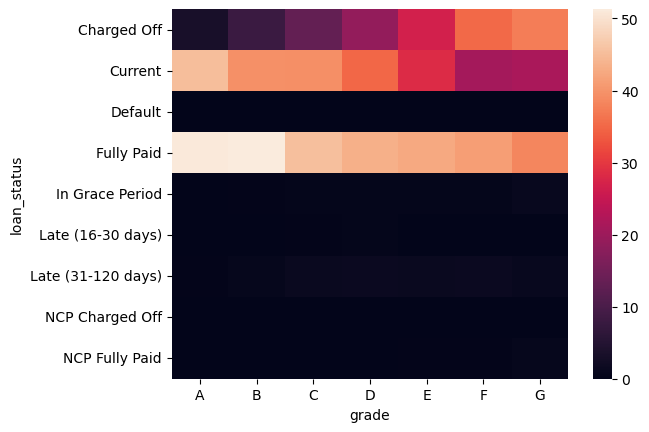

In [ ]:
sns.heatmap(pd.crosstab(fin['loan_status'],fin['grade'],normalize='columns')*100)